Goal - Build Our Own Forest

#Pseudocode:
START

Load Iris Dataset

Split dataset into Train and Test

Create Decision Tree

WHILE stopping condition not reached
    Select best feature
    Split data
    Create child nodes
END WHILE

Predict test samples

Compute Accuracy

STOP

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [2]:
#Load dataset
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name='species')

df = X.copy()
df['species'] = y
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
#Train-Test-Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train size:', len(X_train))
print('Test size:', len(X_test))

Train size: 120
Test size: 30


#Part 1 - Decision Tree Challenge

In [4]:
tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(X_train, y_train)

tree_preds = tree_model.predict(X_test)
tree_acc = accuracy_score(y_test, tree_preds)

print('Decision Tree Accuracy:', round(tree_acc,4))

Decision Tree Accuracy: 0.9667


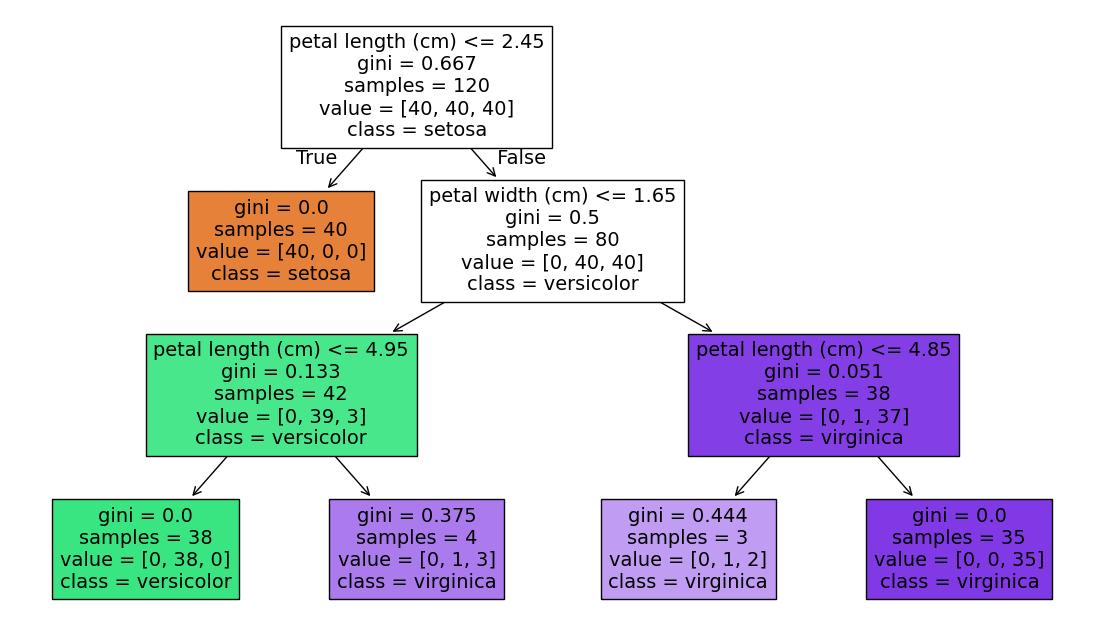

In [5]:
plt.figure(figsize=(14,8))
plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=iris.target_names,
    filled=True
)
plt.show()

#Overfitting Demonstration: Beacuse a very deep tree may memorize training data and generalize poorly.

In [6]:
deep_tree = DecisionTreeClassifier(random_state=42)
deep_tree.fit(X_train, y_train)

train_acc = accuracy_score(y_train, deep_tree.predict(X_train))
test_acc = accuracy_score(y_test, deep_tree.predict(X_test))

print('Deep Tree Training Accuracy:', round(train_acc,4))
print('Deep Tree Testing Accuracy:', round(test_acc,4))

Deep Tree Training Accuracy: 1.0
Deep Tree Testing Accuracy: 0.9333


#Part 2: Random Forest Simulation

In [7]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=3,
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_preds)
print('Random Forest Accuracy:', round(rf_acc,4))

Random Forest Accuracy: 0.9667


In [8]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

importance

,Feature,Importance
2,petal length (cm),0.440338
3,petal width (cm),0.439591
0,sepal length (cm),0.114307
1,sepal width (cm),0.005764


In [9]:
print('Classification Report')
print(classification_report(y_test, rf_preds, target_names=iris.target_names))

Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



#Part 3: Question:

In [10]:
print('Question')
print('Q. If one tree makes a mistake, how can the forest correct it?')
print("Answer: A Random Forest combines predictions from many decision trees. If one tree makes a wrong prediction, the other trees can outvote it. The final prediction is chosen by majority voting, which reduces errors and improves accuracy.")
print("Example: \n")

Question
Q. If one tree makes a mistake, how can the forest correct it?
Answer: A Random Forest combines predictions from many decision trees. If one tree makes a wrong prediction, the other trees can outvote it. The final prediction is chosen by majority voting, which reduces errors and improves accuracy.
Example: 



In [11]:
from collections import Counter

# Predictions from 5 different trees
tree_predictions = [
    "Setosa",      # Tree 1
    "Setosa",      # Tree 2
    "Versicolor",  # Tree 3 (wrong prediction)
    "Setosa",      # Tree 4
    "Setosa"       # Tree 5
]

print("Predictions from individual trees:")
for i, prediction in enumerate(tree_predictions, start=1):
    print(f"Tree {i}: {prediction}")

# Majority Voting
final_prediction = Counter(tree_predictions).most_common(1)[0][0]

print("\nMajority Voting Result:")
print("Final Prediction:", final_prediction)

Predictions from individual trees:
Tree 1: Setosa
Tree 2: Setosa
Tree 3: Versicolor
Tree 4: Setosa
Tree 5: Setosa

Majority Voting Result:
Final Prediction: Setosa
